# Bias–Variance Trade-off

This notebook demonstrates the bias–variance trade-off using the California Housing dataset. We will look at three models:

- High Bias: Linear Regression
- High Variance: Deep Decision Tree
- Balanced: Random Forest

We will see how model complexity affects error behaviour

### Data Understanding

Let's first import the libraries and fetch the data

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

In [ ]:
# Using a dataset from sklearn
data = fetch_california_housing(as_frame=True)
df = data.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Basic Analysis

In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [ ]:
# Checking correlation between numeric values
df.corr(numeric_only=True)['MedHouseVal'].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

<Axes: xlabel='AveRooms', ylabel='MedHouseVal'>

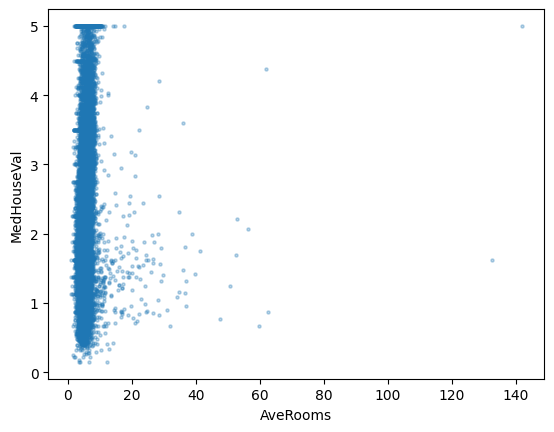

In [ ]:
# Scatter plots between various features and target
df.plot(kind='scatter', x='AveRooms', y='MedHouseVal', s=5, alpha=0.3)  # You can also try using other features here

### Data Splitting and Scaling

Before we scale the features to bring the numeric features to the same scale, we have to split the training and testing sets to prevent leakage. Although scaling is not strictly needed for the three models we are going to build, it is generally a good practice and also improves interpretation.

In [10]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

In [ ]:
# 70-30 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
# Fit the scaler on training data and then fit it to test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Models

We will build three models now. Linear regression will be a simple model that will have a higher bias. We will try to lower the bias in the decision tree model and increase the variance. Finally, we will build a balanced model using random forest.

#### Linear Regression

In [22]:
lin = LinearRegression()
lin.fit(X_train_scaled, y_train)

train_pred = lin.predict(X_train_scaled)
test_pred = lin.predict(X_test_scaled)

print("Linear Regression")
print("Train MAPE:", mean_absolute_percentage_error(y_train, train_pred))
print("Test MAPE :", mean_absolute_percentage_error(y_test, test_pred))

Linear Regression
Train MAPE: 0.3138696575097052
Test MAPE : 0.3285728385155921


The linear regression model shows an error of around 30% in both training and testing. It has a high bias and is underfitting, but giving a similar performance on unseen data as well.

### Decision Tree

We will purposely overfit the decision tree by taking the `max_depth` parameter as 30.

In [25]:
tree = DecisionTreeRegressor(max_depth=30, random_state=1)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

print("Deep Decision Tree")
print("Train MAPE:", mean_absolute_percentage_error(y_train, train_pred))
print("Test MAPE :", mean_absolute_percentage_error(y_test, test_pred))

Deep Decision Tree
Train MAPE: 4.7426207998257794e-05
Test MAPE : 0.24935981949568892


Here the training error is of the order $10^{-3}$% but testing error comes around 25%. This model is clearly overfitting, showing a high variance.

#### Random Forest

Finally, let's use a random forest ensemble to improve generalisability and balance the bias and variance. We will use 300 trees with `max_depth=12` to control overfitting.

In [27]:
rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=1)
rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("Random Forest")
print("Train MAPE:", mean_absolute_percentage_error(y_train, train_pred))
print("Test MAPE :", mean_absolute_percentage_error(y_test, test_pred))

Random Forest
Train MAPE: 0.13267821898318247
Test MAPE : 0.20228862574128345


Here, we can see that averaging reduces variance and trains sufficiently to not overfit and generalise as well

### Bias-Variance Behaviour

Now, we will resample the dataset into multiple training-testing sets and train three decision tree models with varying depths to check how low-high bias models perform

In [ ]:
def evaluate(model_fn, name):
    train_scores, test_scores = [], []

# To evaluate the model variance, we will train each model on 30 random samples
    for _ in range(30):
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3)  # not fixing a random state to ensure 30 random samples
        model = model_fn()
        model.fit(X_tr, y_tr)

        train_scores.append(mean_squared_error(y_tr, model.predict(X_tr)))
        test_scores.append(mean_squared_error(y_te, model.predict(X_te)))

    # calculating average over multiple samples
    print(name)
    print("Avg Train MSE:", np.mean(train_scores))
    print("Avg Test MSE :", np.mean(test_scores))
    print("Variance of Test MSE:", np.var(test_scores))
    print()

evaluate(lambda: DecisionTreeRegressor(max_depth=2), "Decision Tree (Bias)")
evaluate(lambda: DecisionTreeRegressor(max_depth=40), "Decision Tree (Variance)")
evaluate(lambda: DecisionTreeRegressor(max_depth=10), "Decision Tree (Balanced)")

Decision Tree (Bias)
Avg Train MSE: 0.7330593760218048
Avg Test MSE : 0.7492605358729695
Variance of Test MSE: 0.0002005581232468034

Decision Tree (Variance)
Avg Train MSE: 1.538082933431432e-12
Avg Test MSE : 0.5337544172635961
Variance of Test MSE: 0.0004462098737753005

Decision Tree (Balanced)
Avg Train MSE: 0.21485923557625358
Avg Test MSE : 0.417981016493136
Variance of Test MSE: 0.00023150801414794888



Across repeated train–test splits, high-bias models show nearly identical errors each time because their simplified structure dominates, making them stable but inaccurate. High-variance models fluctuate sharply in test error, as small data changes cause large shifts in the fitted model. Balanced models maintain moderate, consistent performance across splits, illustrating controlled variance with sufficient flexibility.